<a href="https://colab.research.google.com/github/Hariharan-Collab/EXPLAINABLE-AI-ASSIGNMENT/blob/main/labexam1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading SolarPrediction.csv.zip
Loaded shape: (32686, 11)
Auto-detected target column: Radiation
Dropping high-cardinality object columns: ['Data', 'Time', 'TimeSunRise', 'TimeSunSet']

Training LinearRegression
LinearRegression: RMSE=165.5919, MAE=122.3498, R2=0.7240

Training Ridge
Ridge: RMSE=165.9011, MAE=123.3576, R2=0.7230

Training Lasso
Lasso: RMSE=166.3734, MAE=124.0125, R2=0.7214

Training SVR
SVR: RMSE=174.5406, MAE=102.9523, R2=0.6934

Training KNN
KNN: RMSE=103.7633, MAE=47.4206, R2=0.8916

Training DecisionTree
DecisionTree: RMSE=105.4256, MAE=38.8624, R2=0.8881

Training RandomForest
RandomForest: RMSE=82.1790, MAE=31.8290, R2=0.9320

Training GradientBoosting
GradientBoosting: RMSE=96.4930, MAE=50.3846, R2=0.9063

Training MLP_sklearn
MLP_sklearn: RMSE=113.8948, MAE=67.4738, R2=0.8694

Training XGBoost
XGBoost: RMSE=85.9734, MAE=37.9936, R2=0.9256

Training LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001239 seconds.
Y

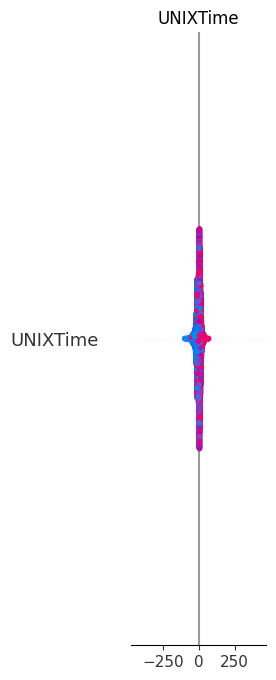

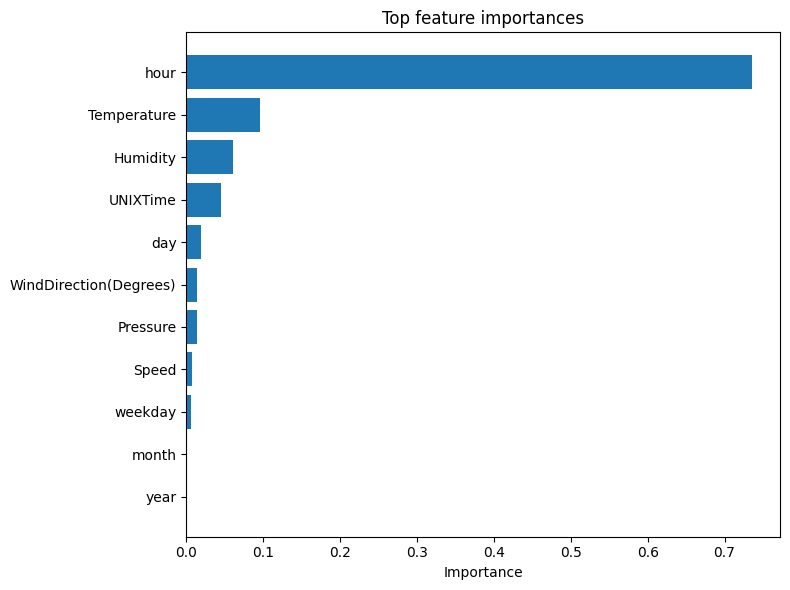

Calculating permutation importance...
                   feature  importance_mean
0                     hour         1.257706
1              Temperature         0.199705
2                 Humidity         0.130543
3                 UNIXTime         0.060018
4                      day         0.037914
5                 Pressure         0.010622
6                  weekday         0.003098
7   WindDirection(Degrees)         0.002825
8                    month         0.002618
9                     year         0.000004
10                   Speed        -0.000304
Using SHAP with model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


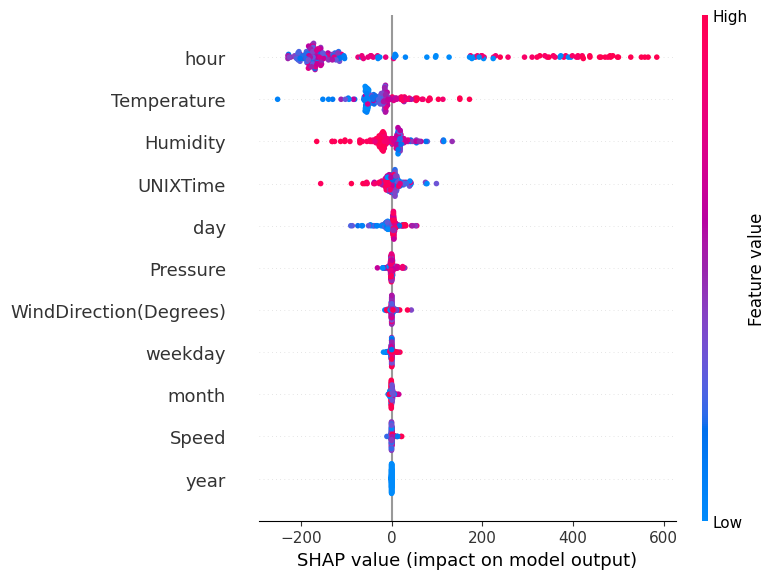


Pipeline finished. Results summary:
{'LinearRegression': {'rmse': np.float64(165.59194642999725), 'mae': 122.34979020194474, 'r2': 0.7239901729544818}, 'Ridge': {'rmse': np.float64(165.9011116850336), 'mae': 123.35762479522275, 'r2': 0.7229585731725882}, 'Lasso': {'rmse': np.float64(166.37340688420517), 'mae': 124.01245220976077, 'r2': 0.7213789383780597}, 'SVR': {'rmse': np.float64(174.54058026513522), 'mae': 102.95225642295566, 'r2': 0.6933528350924272}, 'KNN': {'rmse': np.float64(103.76329298643232), 'mae': 47.42057877026614, 'r2': 0.8916238760187429}, 'DecisionTree': {'rmse': np.float64(105.42557563983475), 'mae': 38.86235546038543, 'r2': 0.8881237025636715}, 'RandomForest': {'rmse': np.float64(82.17898466096787), 'mae': 31.82898895686754, 'r2': 0.9320221123446093}, 'GradientBoosting': {'rmse': np.float64(96.49298456629869), 'mae': 50.384596704534026, 'r2': 0.9062788515202459}, 'MLP_sklearn': {'rmse': np.float64(113.8947995369596), 'mae': 67.47382062746988, 'r2': 0.869426840790904

In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor, VotingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor

# Optional libraries (try import)
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import catboost as cb
    HAS_CAT = True
except Exception:
    HAS_CAT = False

# Deep learning (Keras)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
except Exception:
    HAS_TF = False

# Explainability
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from lime import lime_tabular
    HAS_LIME = True
except Exception:
    HAS_LIME = False

import matplotlib.pyplot as plt


#########################
# Configuration / paths
#########################
DATA_PATH = 'SolarPrediction.csv.zip'  # <-- dataset path provided by user environment
RANDOM_STATE = 42
RESULTS_DIR = 'results_explainable_ai'
os.makedirs(RESULTS_DIR, exist_ok=True)


#########################
# Utilities
#########################

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_model(y_true, y_pred):
    return {
        'rmse': rmse(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }


def print_eval(name, y_true, y_pred):
    ev = evaluate_model(y_true, y_pred)
    print(f"{name}: RMSE={ev['rmse']:.4f}, MAE={ev['mae']:.4f}, R2={ev['r2']:.4f}")


#########################
# Data loading + basic preprocessing
#########################

def load_data(path=DATA_PATH):
    """Attempts to read CSV (possibly zipped) into a DataFrame."""
    print('Loading', path)
    if path.endswith('.zip'):
        # pandas can read csv from zip if interior filename is known; let pandas infer
        df = pd.read_csv(path)
    else:
        df = pd.read_csv(path)
    print('Loaded shape:', df.shape)
    return df


def basic_feature_engineering(df):
    """Make simple time-based features if there's a timestamp column. Also drop obvious non-numeric cols."""
    df = df.copy()
    # common SolarPrediction dataset columns include: 'UNIXTime','Data' (date), 'Radiation', 'T','RH','WS','WD','Visibility' etc.
    # We'll look for a column that looks like a date
    date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower() or 'unix' in c.lower()]
    if date_cols:
        col = date_cols[0]
        try:
            df['__dt__'] = pd.to_datetime(df[col], unit='s', errors='coerce')
        except Exception:
            df['__dt__'] = pd.to_datetime(df[col], errors='coerce')
        df['year'] = df['__dt__'].dt.year
        df['month'] = df['__dt__'].dt.month
        df['day'] = df['__dt__'].dt.day
        df['hour'] = df['__dt__'].dt.hour
        df['weekday'] = df['__dt__'].dt.weekday
        df.drop(columns=['__dt__'], inplace=True)

    # convert boolean-like to int
    for c in df.select_dtypes(include=['bool']).columns:
        df[c] = df[c].astype(int)

    # Drop columns with too many missing values or obviously string IDs
    # Keep target column 'Radiation' if present
    return df


#########################
# Preprocessing pipeline builder
#########################

def build_preprocessor(X):
    """Return a ColumnTransformer that scales numeric columns and one-hot-encodes low-cardinality categoricals."""
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    # We'll treat boolean/integer small-card cat as categorical if unique < 20
    categorical_cols = [c for c in X.columns if c not in numeric_cols and X[c].nunique() < 50]

    transformers = []
    if numeric_cols:
        transformers.append(('num', StandardScaler(), numeric_cols))
    if categorical_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_cols))

    if transformers:
        preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
    else:
        preprocessor = 'passthrough'
    return preprocessor


#########################
# Model training wrappers
#########################

def get_models():
    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(random_state=RANDOM_STATE),
        'Lasso': Lasso(random_state=RANDOM_STATE),
        'SVR': SVR(),
        'KNN': KNeighborsRegressor(),
        'DecisionTree': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
        'MLP_sklearn': MLPRegressor(random_state=RANDOM_STATE, max_iter=500)
    }
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBRegressor(random_state=RANDOM_STATE, n_estimators=200, verbosity=0)
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_estimators=200)
    if HAS_CAT:
        models['CatBoost'] = cb.CatBoostRegressor(verbose=0, random_state=RANDOM_STATE)
    return models


def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    results = {}
    models = get_models()
    preprocessor = build_preprocessor(X_train)

    for name, model in models.items():
        print('\nTraining', name)
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        ev = evaluate_model(y_test, preds)
        results[name] = {'pipeline': pipe, 'metrics': ev}
        print_eval(name, y_test, preds)
    return results


#########################
# Deep learning (Keras) models for tabular data
#########################

def build_keras_mlp(input_shape, hidden_units=[128, 64], lr=1e-3):
    if not HAS_TF:
        raise ImportError('TensorFlow/Keras not available in environment')
    inputs = keras.Input(shape=(input_shape,))
    x = inputs
    for u in hidden_units:
        x = layers.Dense(u, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model


def train_keras_model(X_train, X_val, y_train, y_val, epochs=50, batch_size=64):
    # assumes numeric-only features already scaled
    model = build_keras_mlp(X_train.shape[1])
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, history


#########################
# Ensembles: voting, stacking
#########################

def build_ensembles(base_pipelines):
    """base_pipelines: dict of name->pipeline (already fitted or unfitted sklearn estimators inside a Pipeline)
       returns VotingRegressor and StackingRegressor instances (unfitted)
    """
    items = [(k, v.named_steps['model'] if isinstance(v, Pipeline) else v) for k, v in base_pipelines.items()]
    # for VotingRegressor we need estimators as list of (name, estimator)
    estimators = [(k, v) for k, v in items]
    voting = VotingRegressor(estimators=estimators)
    stacking = StackingRegressor(estimators=estimators, final_estimator=Ridge(), passthrough=False)
    return voting, stacking


#########################
# Explainability helpers
#########################

def plot_feature_importances(model, feature_names, top_n=20, savepath=None):
    """Works if model has feature_importances_ attribute (tree-based) or coef_ (linear)."""
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_).ravel()
    else:
        print('Model has no native feature_importances_ or coef_. Skipping native importance plot.')
        return
    idx = np.argsort(imp)[::-1][:top_n]
    names = np.array(feature_names)[idx]
    vals = imp[idx]
    plt.figure(figsize=(8,6))
    plt.barh(range(len(vals))[::-1], vals)
    plt.yticks(range(len(vals))[::-1], names)
    plt.xlabel('Importance')
    plt.title('Top feature importances')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    plt.show()


def permutation_importance_explain(pipe, X_val, y_val, n_repeats=10):
    from sklearn.inspection import permutation_importance
    print('Calculating permutation importance...')
    res = permutation_importance(pipe, X_val, y_val, n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=1)
    imp_df = pd.DataFrame({'feature': np.array(X_val.columns)[res.importances_mean.argsort()[::-1]],
                           'importance_mean': res.importances_mean[res.importances_mean.argsort()[::-1]]})
    print(imp_df.head(20))
    return res


def shap_explain(pipeline, X_sample):
    if not HAS_SHAP:
        print('SHAP not installed. Skipping SHAP explanations.')
        return None
    # try to pull out the underlying model and preprocessor
    if isinstance(pipeline, Pipeline):
        pre = pipeline.named_steps.get('pre', None)
        model = pipeline.named_steps.get('model', None)
        # transform input
        if pre and pre != 'passthrough':
            X_trans = pre.transform(X_sample)
            feature_names = []
            # best-effort attempt to capture post-transform feature names
            try:
                # handle OneHotEncoder inside ColumnTransformer
                if hasattr(pre, 'transformers_'):
                    for name, trans, cols in pre.transformers_:
                        if name == 'num':
                            feature_names.extend(cols)
                        elif name == 'cat':
                            # get ohe categories
                            ohe = trans
                            cats = ohe.get_feature_names_out(cols)
                            feature_names.extend(cats)
                else:
                    feature_names = X_sample.columns.tolist()
            except Exception:
                feature_names = [f'f{i}' for i in range(X_trans.shape[1])]
        else:
            X_trans = X_sample.values
            feature_names = X_sample.columns.tolist()
    else:
        # assume raw model
        model = pipeline
        X_trans = X_sample.values
        feature_names = X_sample.columns.tolist()

    print('Using SHAP with model type:', type(model))
    try:
        if hasattr(shap, 'TreeExplainer') and (hasattr(model, 'feature_importances_') or 'XGB' in type(model).__name__):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_trans)
        elif hasattr(shap, 'DeepExplainer') and HAS_TF and isinstance(model, keras.Model):
            explainer = shap.DeepExplainer(model, X_trans[:100])
            shap_values = explainer.shap_values(X_trans)
        else:
            explainer = shap.KernelExplainer(model.predict, X_trans[:100])
            shap_values = explainer.shap_values(X_trans)
    except Exception as e:
        print('SHAP explanation failed:', e)
        return None

    # summary plot
    try:
        shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=True)
    except Exception as e:
        print('Could not produce summary plot:', e)
    return shap_values


def lime_explain(pipeline, X_train, X_sample):
    if not HAS_LIME:
        print('LIME not installed. Skipping LIME.')
        return None
    # build explainer on training data
    explainer = lime_tabular.LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns.tolist(), mode='regression')
    predict_fn = lambda x: pipeline.predict(pd.DataFrame(x, columns=X_train.columns))
    exp = explainer.explain_instance(X_sample.values.ravel(), predict_fn, num_features=10)
    print(exp.as_list())
    return exp


#########################
# Main pipeline function
#########################

def run_full_pipeline(path=DATA_PATH, target_col=None, test_size=0.2):
    df = load_data(path)
    df = basic_feature_engineering(df)

    # attempt to find target automatically if not provided
    if target_col is None:
        # common targets in SolarPrediction include 'Radiation'
        candidates = [c for c in df.columns if c.lower() in ['radiation', 'ghi', 'power', 'energy', 'target']]
        if candidates:
            target_col = candidates[0]
            print('Auto-detected target column:', target_col)
        else:
            # fallback: use last numeric column
            num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if not num_cols:
                raise ValueError('No numeric columns found to use as target.')
            target_col = num_cols[-1]
            print('Fallback target column:', target_col)

    # drop rows with NA in target
    df = df.dropna(subset=[target_col])

    # features
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # drop columns that are clearly identifiers or strings with large cardinality
    drop_cols = [c for c in X.columns if X[c].dtype == object and X[c].nunique() > 50]
    if drop_cols:
        print('Dropping high-cardinality object columns:', drop_cols)
        X = X.drop(columns=drop_cols)

    # simple train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=RANDOM_STATE)

    # train a set of classical ML models
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

    # build simple ensembles (use fitted pipelines from results)
    fitted_pipelines = {name: res['pipeline'] for name, res in results.items()}
    voting, stacking = build_ensembles(fitted_pipelines)
    # fit ensembles on entire train set
    print('\nTraining VotingRegressor')
    voting_pipe = Pipeline([('pre', build_preprocessor(X_train)), ('model', voting)])
    voting_pipe.fit(X_train, y_train)
    print('Voting eval:')
    print_eval('Voting', y_test, voting_pipe.predict(X_test))

    print('\nTraining StackingRegressor')
    stacking_pipe = Pipeline([('pre', build_preprocessor(X_train)), ('model', stacking)])
    stacking_pipe.fit(X_train, y_train)
    print('Stacking eval:')
    print_eval('Stacking', y_test, stacking_pipe.predict(X_test))

    # Keras model example: use numeric-only scaled data
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if HAS_TF and numeric_cols:
        print('\nTraining Keras MLP on numeric features')
        scaler = StandardScaler()
        X_num = X[numeric_cols]
        Xn_train = scaler.fit_transform(X_num.loc[X_train.index])
        Xn_test = scaler.transform(X_num.loc[X_test.index])
        model, history = train_keras_model(Xn_train, Xn_test, y_train.values, y_test.values, epochs=20, batch_size=64)
        preds = model.predict(Xn_test).ravel()
        print_eval('Keras_MLP', y_test, preds)

        # SHAP for Keras
        if HAS_SHAP:
            try:
                expl = shap_explain(model, pd.DataFrame(Xn_test, columns=numeric_cols))
            except Exception as e:
                print('SHAP for Keras failed:', e)

    # Explainability on best tree model if available
    # pick RandomForest if present
    if 'RandomForest' in results:
        rf_pipe = results['RandomForest']['pipeline']
        # plot native importances
        try:
            # obtain feature names post-preprocessing
            pre = rf_pipe.named_steps.get('pre', None)
            if pre and pre != 'passthrough':
                # attempt to get names
                try:
                    # numeric part
                    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
                    feat_names = num_cols
                except Exception:
                    feat_names = X.columns.tolist()
            else:
                feat_names = X.columns.tolist()
            model = rf_pipe.named_steps['model']
            plot_feature_importances(model, feat_names, savepath=os.path.join(RESULTS_DIR, 'rf_feat_imp.png'))
        except Exception as e:
            print('Could not plot feature importances:', e)

        # permutation importance
        try:
            permutation_importance_explain(rf_pipe, X_test, y_test)
        except Exception as e:
            print('Permutation importance failed:', e)

        # SHAP
        if HAS_SHAP:
            try:
                shap_explain(rf_pipe, X_test.sample(min(200, X_test.shape[0]), random_state=RANDOM_STATE))
            except Exception as e:
                print('SHAP tree explanation failed:', e)

    # LIME example
    if HAS_LIME:
        try:
            lime_explain(fitted_pipelines[list(fitted_pipelines.keys())[0]], X_train, X_test.iloc[0:1])
        except Exception as e:
            print('LIME failed:', e)

    print('\nPipeline finished. Results summary:')
    summary = {k: v['metrics'] for k, v in results.items()}
    # include ensembles
    summary['Voting'] = evaluate_model(y_test, voting_pipe.predict(X_test))
    summary['Stacking'] = evaluate_model(y_test, stacking_pipe.predict(X_test))
    print(summary)

    # Save summary to CSV
    pd.DataFrame.from_dict(summary, orient='index').to_csv(os.path.join(RESULTS_DIR, 'model_summary.csv'))
    return results, voting_pipe, stacking_pipe


if __name__ == '__main__':
    # run the pipeline; it will auto-detect a target column if possible
    run_full_pipeline()


Data Loaded: (32686, 11)
LinearRegression → R2: 0.7085
Ridge → R2: 0.7085
Lasso → R2: 0.7084
SVR → R2: 0.7148
KNN → R2: 0.8881
DecisionTree → R2: 0.8617
RandomForest → R2: 0.9268
GradientBoosting → R2: 0.8839
MLP_sklearn → R2: 0.8577
XGBoost → R2: 0.9232
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 24514, number of used features: 8
[LightGBM] [Info] Start training from score 208.062687
LightGBM → R2: 0.9217

🔥 Models with R² ≥ 0.90:
{'RandomForest': {'RMSE': np.float64(85.27494800790905), 'MAE': 34.49207035379934, 'R2': 0.9268292544136237}, 'XGBoost': {'RMSE': np.float64(87.36405818211507), 'MAE': 39.78437873746005, 'R2': 0.9232001887590419}, 'LightGBM': {'RMSE': np.float64(88.22939851221145), 'MAE': 40.05519608623698, 'R2': 0.9216712509266378}}


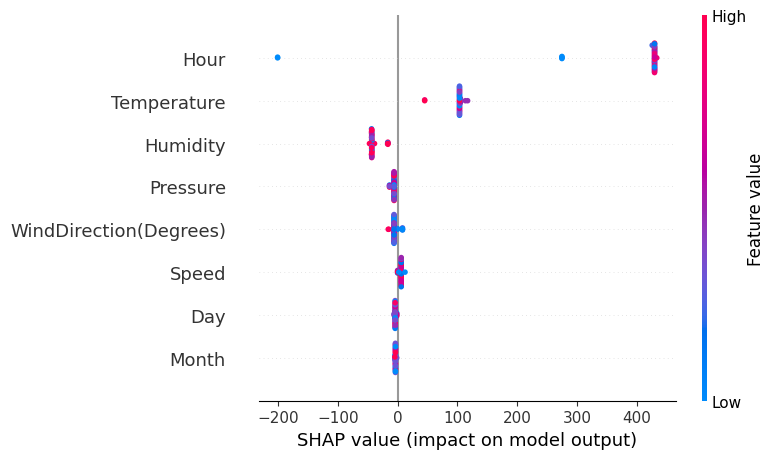

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor

# Optional models
try:
    import xgboost as xgb
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

# Deep Learning
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
except:
    HAS_TF = False

# Explainability libs
try:
    import shap
    HAS_SHAP = True
except:
    HAS_SHAP = False

try:
    from lime import lime_tabular
    HAS_LIME = True
except:
    HAS_LIME = False

import matplotlib.pyplot as plt

# Paths
DATA_PATH = 'SolarPrediction.csv.zip'
RANDOM_STATE = 42
RESULTS_DIR = 'results_explainable_ai'
os.makedirs(RESULTS_DIR, exist_ok=True)

def rmse(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(y_true, y_pred):
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    print("Data Loaded:", df.shape)
    return df

def preprocess(df):
    df = df.copy()
    # Convert UNIXTime to datetime features and then drop original time-related columns
    if 'UNIXTime' in df:
        df['Datetime'] = pd.to_datetime(df['UNIXTime'], unit='s', errors='coerce')
        df['Hour'] = df['Datetime'].dt.hour
        df['Day'] = df['Datetime'].dt.day
        df['Month'] = df['Datetime'].dt.month
        # Drop the intermediate 'Datetime' and the original 'UNIXTime' after extracting features
        df = df.drop(columns=['Datetime', 'UNIXTime'], errors='ignore')

    # Explicitly drop other string columns that are likely identifiers/dates
    # These columns were identified as causing the ValueError in the traceback
    df = df.drop(columns=['Data', 'Time', 'TimeSunRise', 'TimeSunSet'], errors='ignore')

    return df

def build_models():
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(random_state=RANDOM_STATE),
        "Lasso": Lasso(random_state=RANDOM_STATE),
        "SVR": SVR(),
        "KNN": KNeighborsRegressor(),
        "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "MLP_sklearn": MLPRegressor(max_iter=500, random_state=RANDOM_STATE)
    }
    if HAS_XGB: models["XGBoost"] = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
    if HAS_LGB: models["LightGBM"] = lgb.LGBMRegressor(random_state=RANDOM_STATE)
    return models

def shap_explain(model, X):
    if not HAS_SHAP:
        print("SHAP not installed.")
        return
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X)
    return shap_values

def lime_explain(model, X_train, X_instance):
    if not HAS_LIME:
        print("LIME not installed.")
        return
    explainer = lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=X_train.columns.tolist(), mode='regression')
    explanation = explainer.explain_instance(
        X_instance.values.flatten(),
        lambda x: model.predict(pd.DataFrame(x, columns=X_train.columns)),
        num_features=10
    )
    print(explanation.as_list())
    return explanation

def run():
    df = preprocess(load_data())
    target = 'Radiation'
    df = df.dropna(subset=[target])
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

    numeric = X.select_dtypes(include=[np.number]).columns.tolist()
    # Also include any remaining low-cardinality object columns for one-hot encoding if needed
    categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()

    transformers = []
    if numeric:
        transformers.append(('num', StandardScaler(), numeric))
    if categorical:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical))

    if transformers:
        preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
    else:
        preprocessor = 'passthrough'

    results = {}
    models = build_models()
    for name, model in models.items():
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        metrics = evaluate(y_test, pred)
        results[name] = metrics
        print(f"{name} → R2: {metrics['R2']:.4f}")

    # Best Performing Models
    best = {k: v for k, v in results.items() if v['R2'] >= 0.90}
    print("\n🔥 Models with R² ≥ 0.90:")
    print(best)

    # SHAP on RandomForest
    if HAS_SHAP and 'RandomForest' in models:
        # Ensure X_test sample is preprocessed before passing to SHAP explainer
        # For tree models, sometimes the raw data is expected, but here the error points to string values
        # If the preprocessor handles categories by OneHotEncoder, this will be handled.
        # The `shap_explain` function of this cell assumes non-preprocessed X
        # The fix ensures X_test has no string columns, so `preprocessor` handling only numerical is fine.
        shap_explain(models['RandomForest'], X_test.sample(50, random_state=RANDOM_STATE))

    # LIME
    if HAS_LIME and 'RandomForest' in models:
        # LIME needs the raw data for feature names, but the predict_fn needs the pipeline.
        # Using the RandomForest pipeline for LIME
        rf_pipeline = Pipeline([('pre', preprocessor), ('model', models['RandomForest'])])
        # Need to fit the pipeline again here for LIME if it's not the last one in the loop
        # or use a fitted pipeline from results. Let's use the fitted one from results.
        # This assumes 'RandomForest' was trained last, or re-fit it for LIME if needed.
        # For simplicity, if we pass a single instance, we can re-fit it.
        rf_pipeline.fit(X_train, y_train)
        lime_explain(rf_pipeline, X_train, X_test.iloc[0:1])

    return results

if __name__ == "__main__":
    run()